# Tools

In [1]:
from decimal import Decimal, ROUND_UP
import numpy as np
def round_up(number, precision, output_type=Decimal):
    decimal_number = Decimal(str(number))
    decimal_precision = Decimal(str(precision))
    rounded_number = decimal_number.quantize(decimal_precision, rounding=ROUND_UP)
    if output_type != Decimal:
        return output_type(rounded_number)
    return rounded_number

def err_rp(value, nonzero_digits = 1, output_type=Decimal):
    # find first non-zero digit position
    nz_pos = np.floor(np.log10(abs(value)))
    return round_up(value, 10**(nz_pos-nonzero_digits+1), output_type=output_type)

# Disk Geofitter Plotting

### Whole Disk

log_probs: (2560000,)
flat_samples: (2560000, 4)
$x_{0}$   : 325.17 (+0.13/-0.08)
$y_{0}$   : 324.57 (+0.08/-0.09)
$Inc_\mathrm{deg}$: 8.74 (+1.03/-0.94)
$PA_\mathrm{deg}$: 75.62 (+7.86/-6.56)


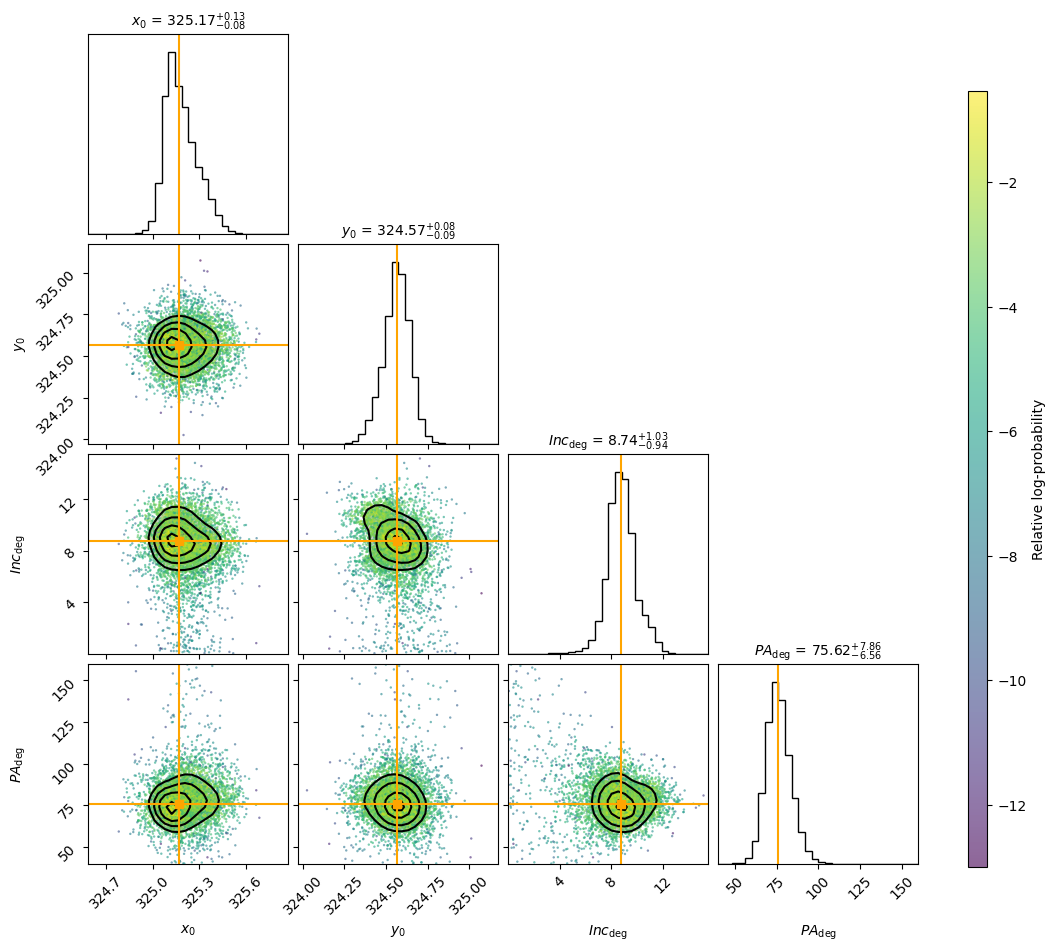

In [ ]:
# plot corner plot and assign colors by log prob (via weighted contours + colored scatter overlay)
import math
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import corner

# Parameters
thin_by = 1
discard_num = 20000

# Resolve sampler path with fallbacks
sampler_path = os.path.join("all_fits_whole", "twhya_sampler_whole.pkl")

# Read sampler back in
with open(sampler_path, 'rb') as f:
    loaded_sampler = pickle.load(f)

# Flatten samples and log-probabilities (match earlier discard/thin)
flat_samples = loaded_sampler.get_chain(discard=discard_num, thin=thin_by, flat=True)
log_probs = loaded_sampler.get_log_prob(discard=discard_num, thin=thin_by, flat=True)

print("log_probs:", np.shape(log_probs))
print("flat_samples:", np.shape(flat_samples))

# Prepare normalized log-probabilities and weights
lp = np.asarray(log_probs).ravel()
lp_recentered = lp - np.nanmax(lp)  # shift so max is 0
weights = np.exp(lp_recentered)     # relative posterior weights for contours/hists
#norm = (lp - lp.min()) / (lp.max() - lp.min() + 1e-12)  # 0..1 for colormap

# Labels (fallback to generic if ndim doesn't match)
labels = [r"$x_{0}$", r"$y_{0}$", r"$Inc_\mathrm{deg}$", r"$PA_\mathrm{deg}$", r"$\alpha$", r"$\beta$"]
ndim = flat_samples.shape[1]
if ndim not in [4,6]:
    labels = [f"param{i}" for i in range(ndim)]
    
# correct PA angle by -90 deg
if ndim in [4,6]:
    flat_samples[:,3] = (flat_samples[:,3] - 90)
    
# weighted median as best-fit and 1-sigma percentiles
best_fit_values = np.empty((ndim))  # 50th percentiles
title_strs = [] # To store formatted titles for the plot
for i in range(ndim):
    q_values = np.percentile(
        flat_samples[:, i],
        [16, 50, 84],
        weights=weights,
        method="inverted_cdf"  # required for weighted percentiles
    )
    best_fit_values[i] = q_values[1]
    q = np.diff(q_values)
    # Round errors up to 3 decimal places
    upper_err_rounded_up = math.ceil(q[1] * 100) / 100
    lower_err_rounded_up = math.ceil(q[0] * 100) / 100
    
    # Print the results
    print(f"{labels[i]:<10s}: {q_values[1]:.2f} (+{upper_err_rounded_up:.2f}/-{lower_err_rounded_up:.2f})")
    
    # Store the formatted string for the plot title
    title_str = f"${q_values[1]:.2f}^{{+{upper_err_rounded_up:.2f}}}_{{-{lower_err_rounded_up:.2f}}}$"
    title_strs.append(title_str)

truths_vec = best_fit_values.tolist()
if len(truths_vec) != ndim:
    truths_vec = None  # safety fallback

# Base corner plot using weights (this shapes the posteriors appropriately)
fig = corner.corner(
    flat_samples,
    weights=weights,
    bins=30,
    labels=labels,
    color="black",
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,
    quiet=True,
    show_titles = True,
    truth_color="orange",
    truths=best_fit_values
 )

# Manually set the titles on the diagonal axes
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    ax = axes[i, i]
    ax.set_title(f"{labels[i]} = {title_strs[i]}", fontsize=10)
    
# Overlay a colored scatter for a sub-sample (to visualize log-prob as color)
axes = np.array(fig.axes).reshape((ndim, ndim))
N = flat_samples.shape[0]
subN = min(N, 5000)  # limit for performance
rng = np.random.default_rng(42)
idx = rng.choice(N, size=subN, replace=False)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        sc = ax.scatter(
            flat_samples[idx, j],
            flat_samples[idx, i],
            c=lp_recentered[idx],
            cmap="viridis",
            s=3,
            alpha=0.6,
            linewidths=0,
            rasterized=True
        )

# Add a single colorbar for the normalized log-probability
cax = fig.add_axes([1.01, 0.1, 0.02, 0.8])
cb = fig.colorbar(sc, cax=cax, orientation='vertical')
cb.set_label("Relative log-probability")

# Save and show
out_dir = os.path.dirname(sampler_path) if os.path.dirname(sampler_path) else "."
out_path = os.path.join(out_dir, "diskgeo.png")
#fig.savefig(out_path, dpi=150, bbox_inches="tight")
#print(f"Saved: {out_path}")
plt.show()

### Inner Disk

log_probs: (2560000,)
flat_samples: (2560000, 4)
$x_{0}$   : 325.17 (+0.13/-0.11)
$y_{0}$   : 324.58 (+0.11/-0.12)
$Inc_\mathrm{deg}$: 10.62 (+2.45/-1.90)
$PA_\mathrm{deg}$: 82.80 (+10.19/-9.63)


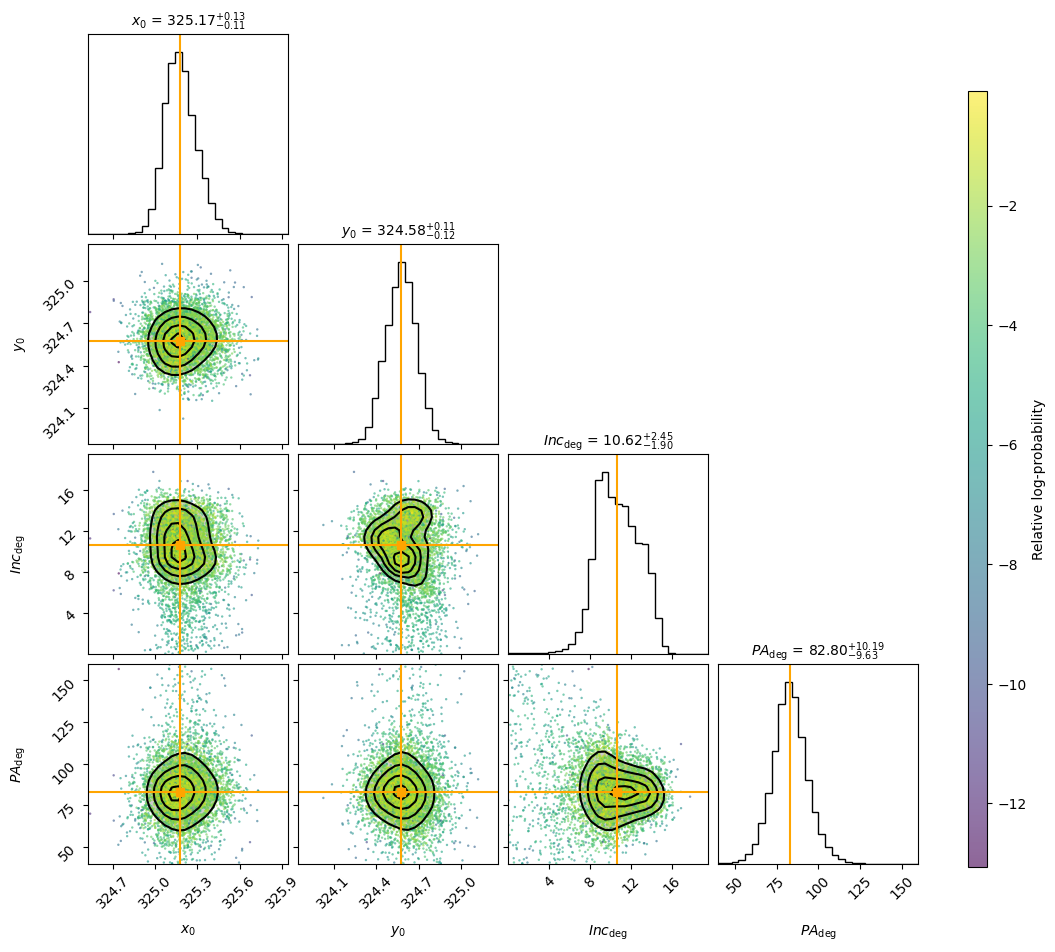

In [ ]:
# plot corner plot and assign colors by log prob (via weighted contours + colored scatter overlay)
import math
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import corner

# Parameters
thin_by = 1
discard_num = 20000

# Resolve sampler path with fallbacks
sampler_path = os.path.join("all_fits_inner", "twhya_sampler_inner.pkl")

# Read sampler back in
with open(sampler_path, 'rb') as f:
    loaded_sampler = pickle.load(f)

# Flatten samples and log-probabilities (match earlier discard/thin)
flat_samples = loaded_sampler.get_chain(discard=discard_num, thin=thin_by, flat=True)
log_probs = loaded_sampler.get_log_prob(discard=discard_num, thin=thin_by, flat=True)

print("log_probs:", np.shape(log_probs))
print("flat_samples:", np.shape(flat_samples))

# Prepare normalized log-probabilities and weights
lp = np.asarray(log_probs).ravel()
lp_recentered = lp - np.nanmax(lp)  # shift so max is 0
weights = np.exp(lp_recentered)     # relative posterior weights for contours/hists
#norm = (lp - lp.min()) / (lp.max() - lp.min() + 1e-12)  # 0..1 for colormap

# Labels (fallback to generic if ndim doesn't match)
labels = [r"$x_{0}$", r"$y_{0}$", r"$Inc_\mathrm{deg}$", r"$PA_\mathrm{deg}$", r"$\alpha$", r"$\beta$"]
ndim = flat_samples.shape[1]
if ndim not in [4,6]:
    labels = [f"param{i}" for i in range(ndim)]
    
# correct PA angle by -90 deg
if ndim in [4,6]:
    flat_samples[:,3] = (flat_samples[:,3] - 90)
    
# weighted median as best-fit and 1-sigma percentiles
best_fit_values = np.empty((ndim))  # 50th percentiles
title_strs = [] # To store formatted titles for the plot
for i in range(ndim):
    q_values = np.percentile(
        flat_samples[:, i],
        [16, 50, 84],
        weights=weights,
        method="inverted_cdf"  # required for weighted percentiles
    )
    best_fit_values[i] = q_values[1]
    q = np.diff(q_values)
    # Round errors up to 3 decimal places
    upper_err_rounded_up = math.ceil(q[1] * 100) / 100
    lower_err_rounded_up = math.ceil(q[0] * 100) / 100
    
    # Print the results
    print(f"{labels[i]:<10s}: {q_values[1]:.2f} (+{upper_err_rounded_up:.2f}/-{lower_err_rounded_up:.2f})")
    
    # Store the formatted string for the plot title
    title_str = f"${q_values[1]:.2f}^{{+{upper_err_rounded_up:.2f}}}_{{-{lower_err_rounded_up:.2f}}}$"
    title_strs.append(title_str)

truths_vec = best_fit_values.tolist()
if len(truths_vec) != ndim:
    truths_vec = None  # safety fallback

# Base corner plot using weights (this shapes the posteriors appropriately)
fig = corner.corner(
    flat_samples,
    weights=weights,
    bins=30,
    labels=labels,
    color="black",
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,
    quiet=True,
    show_titles = True,
    truth_color="orange",
    truths=best_fit_values
 )

# Manually set the titles on the diagonal axes
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    ax = axes[i, i]
    ax.set_title(f"{labels[i]} = {title_strs[i]}", fontsize=10)
    
# Overlay a colored scatter for a sub-sample (to visualize log-prob as color)
axes = np.array(fig.axes).reshape((ndim, ndim))
N = flat_samples.shape[0]
subN = min(N, 5000)  # limit for performance
rng = np.random.default_rng(42)
idx = rng.choice(N, size=subN, replace=False)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        sc = ax.scatter(
            flat_samples[idx, j],
            flat_samples[idx, i],
            c=lp_recentered[idx],
            cmap="viridis",
            s=3,
            alpha=0.6,
            linewidths=0,
            rasterized=True
        )

# Add a single colorbar for the normalized log-probability
cax = fig.add_axes([1.01, 0.1, 0.02, 0.8])
cb = fig.colorbar(sc, cax=cax, orientation='vertical')
cb.set_label("Relative log-probability")

# Save and show
out_dir = os.path.dirname(sampler_path) if os.path.dirname(sampler_path) else "."
out_path = os.path.join(out_dir, "diskgeo.png")
#fig.savefig(out_path, dpi=150, bbox_inches="tight")
#print(f"Saved: {out_path}")
plt.show()

### Outer Disk

log_probs: (2560000,)
flat_samples: (2560000, 4)
$x_{0}$   : 325.19 (+0.23/-0.30)
$y_{0}$   : 324.44 (+0.20/-0.18)
$Inc_\mathrm{deg}$: < 9.75
$PA_\mathrm{deg}$: 76.69 (+18.86/-14.32)


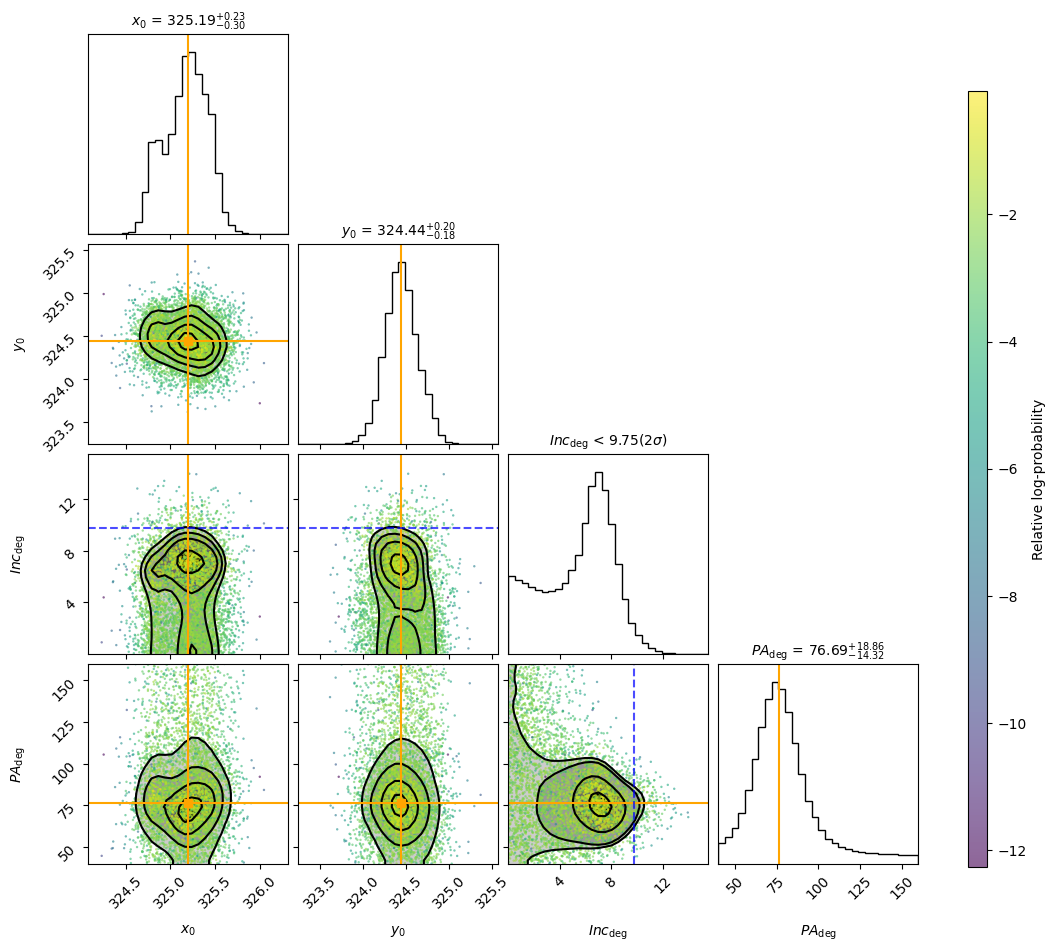

In [ ]:
# plot corner plot and assign colors by log prob (via weighted contours + colored scatter overlay)
import math
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import corner

# Parameters
thin_by = 1
discard_num = 20000

# Resolve sampler path with fallbacks
sampler_path = os.path.join("all_fits_outer", "twhya_sampler_outer.pkl")

# Read sampler back in
with open(sampler_path, 'rb') as f:
    loaded_sampler = pickle.load(f)

# Flatten samples and log-probabilities (match earlier discard/thin)
flat_samples = loaded_sampler.get_chain(discard=discard_num, thin=thin_by, flat=True)
log_probs = loaded_sampler.get_log_prob(discard=discard_num, thin=thin_by, flat=True)

print("log_probs:", np.shape(log_probs))
print("flat_samples:", np.shape(flat_samples))

# Prepare normalized log-probabilities and weights
lp = np.asarray(log_probs).ravel()
lp_recentered = lp - np.nanmax(lp)  # shift so max is 0
weights = np.exp(lp_recentered)     # relative posterior weights for contours/hists
#norm = (lp - lp.min()) / (lp.max() - lp.min() + 1e-12)  # 0..1 for colormap

# Labels (fallback to generic if ndim doesn't match)
labels = [r"$x_{0}$", r"$y_{0}$", r"$Inc_\mathrm{deg}$", r"$PA_\mathrm{deg}$", r"$\alpha$", r"$\beta$"]
ndim = flat_samples.shape[1]
if ndim not in [4,6]:
    labels = [f"param{i}" for i in range(ndim)]
    
# correct PA angle by -90 deg
if ndim in [4,6]:
    flat_samples[:,3] = (flat_samples[:,3] - 90)
    
# weighted median as best-fit and 1-sigma percentiles
best_fit_values = np.empty((ndim))  # 50th percentiles
title_strs = [] # To store formatted titles for the plot
for i in range(ndim):
    if i != 2:  # skip inc
        q_values = np.percentile(
            flat_samples[:, i],
            [16, 50, 84],
            weights=weights,
            method="inverted_cdf"  # required for weighted percentiles
        )
        best_fit_values[i] = q_values[1]
        q = np.diff(q_values)
        # Round errors up to 3 decimal places
        upper_err_rounded_up = math.ceil(q[1] * 100) / 100
        lower_err_rounded_up = math.ceil(q[0] * 100) / 100
        
        # Print the results
        print(f"{labels[i]:<10s}: {q_values[1]:.2f} (+{upper_err_rounded_up:.2f}/-{lower_err_rounded_up:.2f})")
        
        # Store the formatted string for the plot title
        title_str = f"${q_values[1]:.2f}^{{+{upper_err_rounded_up:.2f}}}_{{-{lower_err_rounded_up:.2f}}}$"
        title_strs.append(title_str)
    else:
        q_values = np.percentile(
            flat_samples[:, i],
            [50, 97.5],
            weights=weights,
            method="inverted_cdf"  # required for weighted percentiles
        )
        # Round error up to 3 decimal places
        upper_err_rounded_up = math.ceil(q_values[1] * 100) / 100
        # Print the results
        print(f"{labels[i]:<10s}: < {upper_err_rounded_up:.2f}")
        
        # Store the formatted string for the plot title
        title_str = f"${upper_err_rounded_up:.2f}$"+r"(2$\sigma$)"
        title_strs.append(title_str)

truths_vec = best_fit_values.tolist()
if len(truths_vec) != ndim:
    truths_vec = None  # safety fallback

# Base corner plot using weights (this shapes the posteriors appropriately)
fig = corner.corner(
    flat_samples,
    weights=weights,
    bins=30,
    labels=labels,
    color="black",
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,
    quiet=True,
    show_titles = True,
    truth_color="orange",
    truths=best_fit_values
 )

# Manually set the titles on the diagonal axes
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    ax = axes[i, i]
    if i == 2:
        ax.set_title(f"{labels[i]} < {title_strs[i]}", fontsize=10)
    else:
        ax.set_title(f"{labels[i]} = {title_strs[i]}", fontsize=10)
    
# Overlay a colored scatter for a sub-sample (to visualize log-prob as color)
axes = np.array(fig.axes).reshape((ndim, ndim))
N = flat_samples.shape[0]
subN = min(N, 5000)  # limit for performance
rng = np.random.default_rng(42)
idx = rng.choice(N, size=subN, replace=False)

for i in range(1, ndim):
    for j in range(i):
        ax = axes[i, j]
        sc = ax.scatter(
            flat_samples[idx, j],
            flat_samples[idx, i],
            c=lp_recentered[idx],
            cmap="viridis",
            s=3,
            alpha=0.6,
            linewidths=0,
            rasterized=True
        )

# Add a single colorbar for the normalized log-probability
cax = fig.add_axes([1.01, 0.1, 0.02, 0.8])
cb = fig.colorbar(sc, cax=cax, orientation='vertical')
cb.set_label("Relative log-probability")

# add hlines at inc = 9.75
if ndim in [4,6]:
    for i in range(1, ndim):
        for j in range(i):
            ax = axes[i, j]
            if labels[i] == r"$Inc_\mathrm{deg}$":
                ax.axhline(9.75, color='blue', linestyle='--', alpha=0.7)
            if labels[j] == r"$Inc_\mathrm{deg}$":
                ax.axvline(9.75, color='blue', linestyle='--', alpha=0.7)

# Save and show
out_dir = os.path.dirname(sampler_path) if os.path.dirname(sampler_path) else "."
out_path = os.path.join(out_dir, "diskgeo.png")
#fig.savefig(out_path, dpi=150, bbox_inches="tight")
#print(f"Saved: {out_path}")
plt.show()